In [18]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
solar_data = pd.read_csv('data/solarpower.csv')
solar_data.head()

,date,cum_power
0,2017-01-01,20111.0
1,2017-01-02,20112.0
2,2017-01-03,20115.0
3,2017-01-04,20117.0
4,2017-01-05,20119.0


In [4]:
# Находим индексы, где cum_power == -1
missing_indices = solar_data[solar_data['cum_power'] == -1].index

# Обрабатываем каждый пропуск
for idx in missing_indices:
    if idx > 0 and idx < len(solar_data) - 1:
        prev_val = solar_data.at[idx - 1, 'cum_power']
        next_val = solar_data.at[idx + 1, 'cum_power']
        if prev_val != -1 and next_val != -1:
            solar_data.at[idx, 'cum_power'] = (prev_val + next_val) / 2

In [5]:
# Вычисление среднего и округление
mean_value = round(solar_data['cum_power'].mean())
print(mean_value)

23848


Шаг 1: Создать столбец day_power — ежедневная выработка энергии:

In [6]:
solar_data['day_power'] = solar_data['cum_power'].diff()
solar_data.head()

,date,cum_power,day_power
0,2017-01-01,20111.0,NaN
1,2017-01-02,20112.0,1.0
2,2017-01-03,20115.0,3.0
3,2017-01-04,20117.0,2.0
4,2017-01-05,20119.0,2.0


Шаг 2: Преобразовать date в формат datetime, если это ещё не сделано:

In [7]:
solar_data['date'] = pd.to_datetime(solar_data['date'])

Шаг 3: Получить период “год-месяц”:

In [17]:
solar_data['period'] = solar_data['date'].dt.to_period('M')
solar_data.head()

,date,cum_power,day_power,period
0,2017-01-01,20111.0,NaN,2017-01
1,2017-01-02,20112.0,1.0,2017-01
2,2017-01-03,20115.0,3.0,2017-01
3,2017-01-04,20117.0,2.0,2017-01
4,2017-01-05,20119.0,2.0,2017-01


Шаг 4: Посчитать среднюю суточную выработку по каждому месяцу:

In [16]:
monthly_avg = solar_data.groupby('period')['day_power'].mean()
print(monthly_avg)
display(solar_data.head(90))

period
2017-01     3.233333
2017-02     3.714286
2017-03    10.774194
2017-04    16.300000
2017-05    19.000000
2017-06    21.500000
2017-07    18.129032
2017-08    15.064516
2017-09    11.533333
2017-10     6.419355
2017-11     3.233333
2017-12     1.161290
2018-01     2.064516
2018-02     6.928571
2018-03     8.709677
2018-04    14.633333
2018-05    21.032258
2018-06    18.766667
2018-07    22.000000
2018-08    17.096774
2018-09    13.866667
2018-10     9.000000
Freq: M, Name: day_power, dtype: float64


,date,cum_power,day_power,period
0,2017-01-01,20111.0,NaN,2017-01
1,2017-01-02,20112.0,1.0,2017-01
2,2017-01-03,20115.0,3.0,2017-01
3,2017-01-04,20117.0,2.0,2017-01
4,2017-01-05,20119.0,2.0,2017-01
...,...,...,...,...
85,2017-03-27,20578.0,20.0,2017-03
86,2017-03-28,20599.0,21.0,2017-03
87,2017-03-29,20616.0,17.0,2017-03
88,2017-03-30,20626.0,10.0,2017-03


Шаг 5: Получить значение для марта 2017:

In [11]:
march_2017_avg = round(monthly_avg.loc['2017-03'])
print(march_2017_avg)

11


Постройте график временного ряда — средней ежедневной выработки солнечной энергии на каждый месяц-год. Не забудьте подписать оси и сам график.

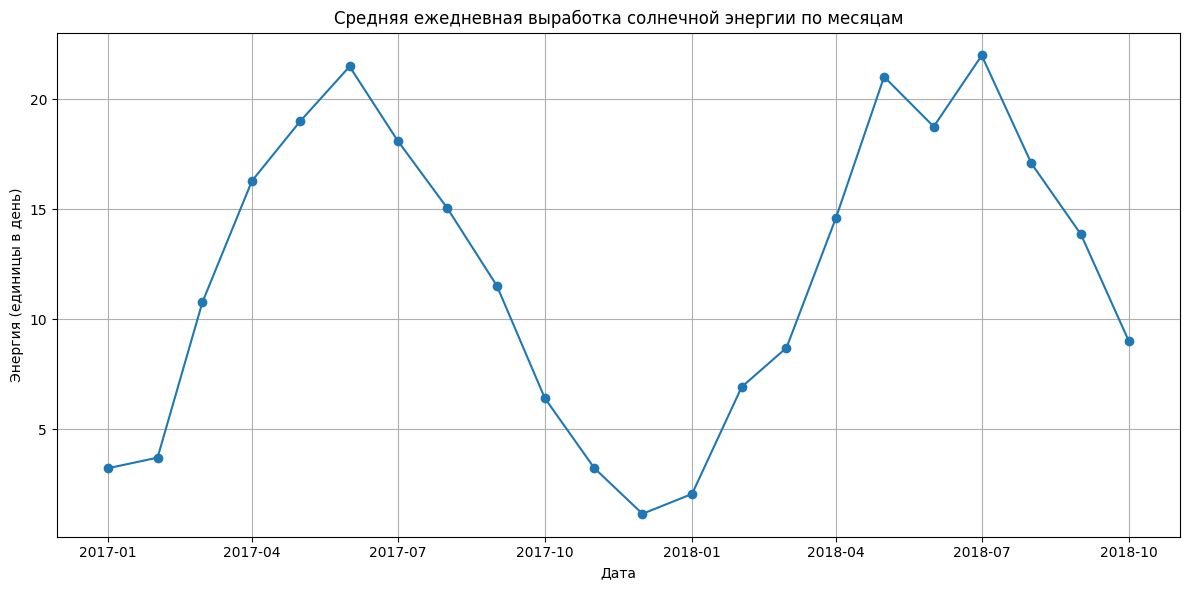

In [19]:
# Преобразуем index в datetime для графика
monthly_avg.index = monthly_avg.index.to_timestamp()

# Строим график
plt.figure(figsize=(12, 6))
plt.plot(monthly_avg.index, monthly_avg.values, marker='o', linestyle='-')
plt.title('Средняя ежедневная выработка солнечной энергии по месяцам')
plt.xlabel('Дата')
plt.ylabel('Энергия (единицы в день)')
plt.grid(True)
plt.tight_layout()
plt.show()